# Exploratory Data Analysis: Two-Stage Anaerobic Digestion Dataset

Raw file: `ad_two_stage_raw.csv`

This notebook explores a two-stage anaerobic digestion dataset with measurements at three process points:

- `inf_*`: influent/feed
- `acid_*`: acidogenic-stage effluent
- `meth_*`: methanogenic-stage effluent

The dataset also includes `biogas_flow_m3d`, which can be treated as a production-performance target.

EDA goals:

- Check data structure, completeness, and date coverage.
- Engineer stage-wise COD, solids, and nitrogen removal/change metrics.
- Explore overall CODt/CODs removal and biogas production behavior.
- Identify candidate upstream relationships for future predictive modeling.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load Raw Data


In [2]:
raw_data = "ad_two_stage_raw.csv"

df = pd.read_csv(raw_data)
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

numeric_cols = df.columns.drop("date")
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

df = df.sort_values("date").reset_index(drop=True)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Rows: 70
Columns: 26
Date range: 2025-04-01 to 2025-11-28


,date,inf_pH,inf_temp,inf_CODt,inf_CODs,inf_TKN,inf_NH4N,inf_TS,inf_VS,acid_pH,acid_temp,acid_CODt,acid_CODs,acid_TKN,acid_NH4N,acid_TS,acid_VS,meth_pH,meth_temp,meth_CODt,meth_CODs,meth_TKN,meth_NH4N,meth_TS,meth_VS,biogas_flow_m3d
0,2025-04-01,7.62,25.90,64217,24797,2198,1243,33999,27045,5.44,25.90,52223,32771,2258,1495,28984,23004,6.97,26.00,18509,7169,2035,1480,18694,12312,200.73
1,2025-04-04,6.94,28.60,78947,34032,1933,1215,44044,31948,5.32,29.20,70319,51858,1945,1296,39673,24529,7.16,29.30,30712,10993,1665,1258,29379,14827,249.66
2,2025-04-08,6.96,26.80,65382,21311,2691,2028,35109,28226,5.85,26.80,53348,34587,2766,2244,28971,23492,6.90,26.80,18223,7028,2509,2384,17504,10716,171.16
3,2025-04-11,6.84,28.30,68754,21823,1962,1084,37935,29630,5.40,28.70,56387,26833,1840,1177,33475,26272,6.86,28.60,29803,8113,1665,1303,24376,16235,150.52
4,2025-04-15,6.98,27.20,59728,17654,2212,1369,32222,25158,5.46,28.00,47304,32008,2167,1476,29478,20281,7.26,27.90,19405,6246,1880,1415,18089,10182,169.13


In [3]:
for prefix in ["inf", "acid", "meth"]:
    cols = [c for c in df.columns if c.startswith(prefix + "_")]
    print(f"{prefix}: {len(cols)} columns -> {cols}")


inf: 8 columns -> ['inf_pH', 'inf_temp', 'inf_CODt', 'inf_CODs', 'inf_TKN', 'inf_NH4N', 'inf_TS', 'inf_VS']
acid: 8 columns -> ['acid_pH', 'acid_temp', 'acid_CODt', 'acid_CODs', 'acid_TKN', 'acid_NH4N', 'acid_TS', 'acid_VS']
meth: 8 columns -> ['meth_pH', 'meth_temp', 'meth_CODt', 'meth_CODs', 'meth_TKN', 'meth_NH4N', 'meth_TS', 'meth_VS']


## 2. Missingness and Data Types


In [4]:
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_pct", ascending=False)
)
missing


,missing_count,missing_pct
date,0,0.00
inf_pH,0,0.00
inf_temp,0,0.00
inf_CODt,0,0.00
inf_CODs,0,0.00
inf_TKN,0,0.00
inf_NH4N,0,0.00
inf_TS,0,0.00
inf_VS,0,0.00
acid_pH,0,0.00


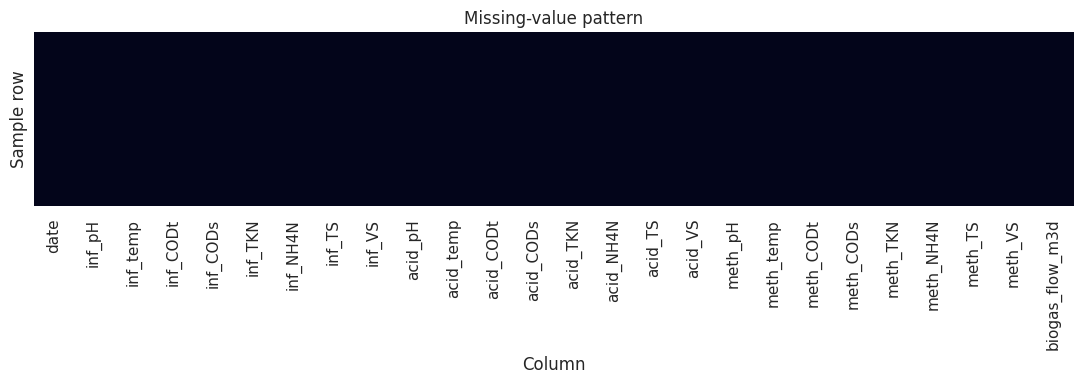

In [5]:
plt.figure(figsize=(11, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Missing-value pattern")
plt.xlabel("Column")
plt.ylabel("Sample row")
plt.tight_layout()
plt.show()


## 3. Target and Stage-Performance Engineering


In [6]:
def safe_ratio(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def removal_pct(upstream, downstream):
    upstream = upstream.replace(0, np.nan)
    return (upstream - downstream) / upstream * 100

eda = df.copy()

# Overall removal from influent to methanogenic effluent.
eda["overall_CODt_removal_pct"] = removal_pct(eda["inf_CODt"], eda["meth_CODt"])
eda["overall_CODs_removal_pct"] = removal_pct(eda["inf_CODs"], eda["meth_CODs"])
eda["overall_TS_removal_pct"] = removal_pct(eda["inf_TS"], eda["meth_TS"])
eda["overall_VS_removal_pct"] = removal_pct(eda["inf_VS"], eda["meth_VS"])

# Acid-stage change from influent to acidogenic effluent.
eda["acid_CODt_removal_pct"] = removal_pct(eda["inf_CODt"], eda["acid_CODt"])
eda["acid_CODs_change_pct"] = removal_pct(eda["inf_CODs"], eda["acid_CODs"])
eda["acid_TS_removal_pct"] = removal_pct(eda["inf_TS"], eda["acid_TS"])
eda["acid_VS_removal_pct"] = removal_pct(eda["inf_VS"], eda["acid_VS"])

# Meth-stage change from acidogenic to methanogenic effluent.
eda["meth_CODt_removal_pct"] = removal_pct(eda["acid_CODt"], eda["meth_CODt"])
eda["meth_CODs_removal_pct"] = removal_pct(eda["acid_CODs"], eda["meth_CODs"])
eda["meth_TS_removal_pct"] = removal_pct(eda["acid_TS"], eda["meth_TS"])
eda["meth_VS_removal_pct"] = removal_pct(eda["acid_VS"], eda["meth_VS"])

# Composition ratios and process deltas.
for stage in ["inf", "acid", "meth"]:
    eda[f"{stage}_CODs_to_CODt_ratio"] = safe_ratio(eda[f"{stage}_CODs"], eda[f"{stage}_CODt"])
    eda[f"{stage}_VS_to_TS_ratio"] = safe_ratio(eda[f"{stage}_VS"], eda[f"{stage}_TS"])
    eda[f"{stage}_NH4N_to_TKN_ratio"] = safe_ratio(eda[f"{stage}_NH4N"], eda[f"{stage}_TKN"])

eda["acid_minus_inf_pH"] = eda["acid_pH"] - eda["inf_pH"]
eda["meth_minus_acid_pH"] = eda["meth_pH"] - eda["acid_pH"]
eda["meth_minus_inf_pH"] = eda["meth_pH"] - eda["inf_pH"]
eda["acid_minus_inf_temp"] = eda["acid_temp"] - eda["inf_temp"]
eda["meth_minus_acid_temp"] = eda["meth_temp"] - eda["acid_temp"]

performance_cols = [
    "overall_CODt_removal_pct", "overall_CODs_removal_pct",
    "acid_CODt_removal_pct", "acid_CODs_change_pct",
    "meth_CODt_removal_pct", "meth_CODs_removal_pct",
    "overall_TS_removal_pct", "overall_VS_removal_pct",
    "biogas_flow_m3d",
]

eda[performance_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
overall_CODt_removal_pct,70.00,66.59,4.64,56.24,63.41,67.40,70.22,73.75
overall_CODs_removal_pct,70.00,66.01,7.74,39.43,62.60,66.61,71.62,80.65
acid_CODt_removal_pct,70.00,15.13,4.51,7.23,11.24,15.33,18.78,21.86
acid_CODs_change_pct,70.00,-46.66,20.02,-97.90,-57.78,-44.15,-31.36,-13.30
meth_CODt_removal_pct,70.00,60.61,5.14,47.15,57.41,60.25,64.08,70.81
meth_CODs_removal_pct,70.00,76.86,3.97,66.98,74.74,77.23,80.34,83.03
overall_TS_removal_pct,70.00,41.98,5.23,31.80,38.67,42.25,45.47,51.39
overall_VS_removal_pct,70.00,55.10,4.71,44.83,51.65,55.19,58.61,65.11
biogas_flow_m3d,70.00,198.60,40.64,120.00,171.68,198.20,221.70,300.61


## 4. Time Trends


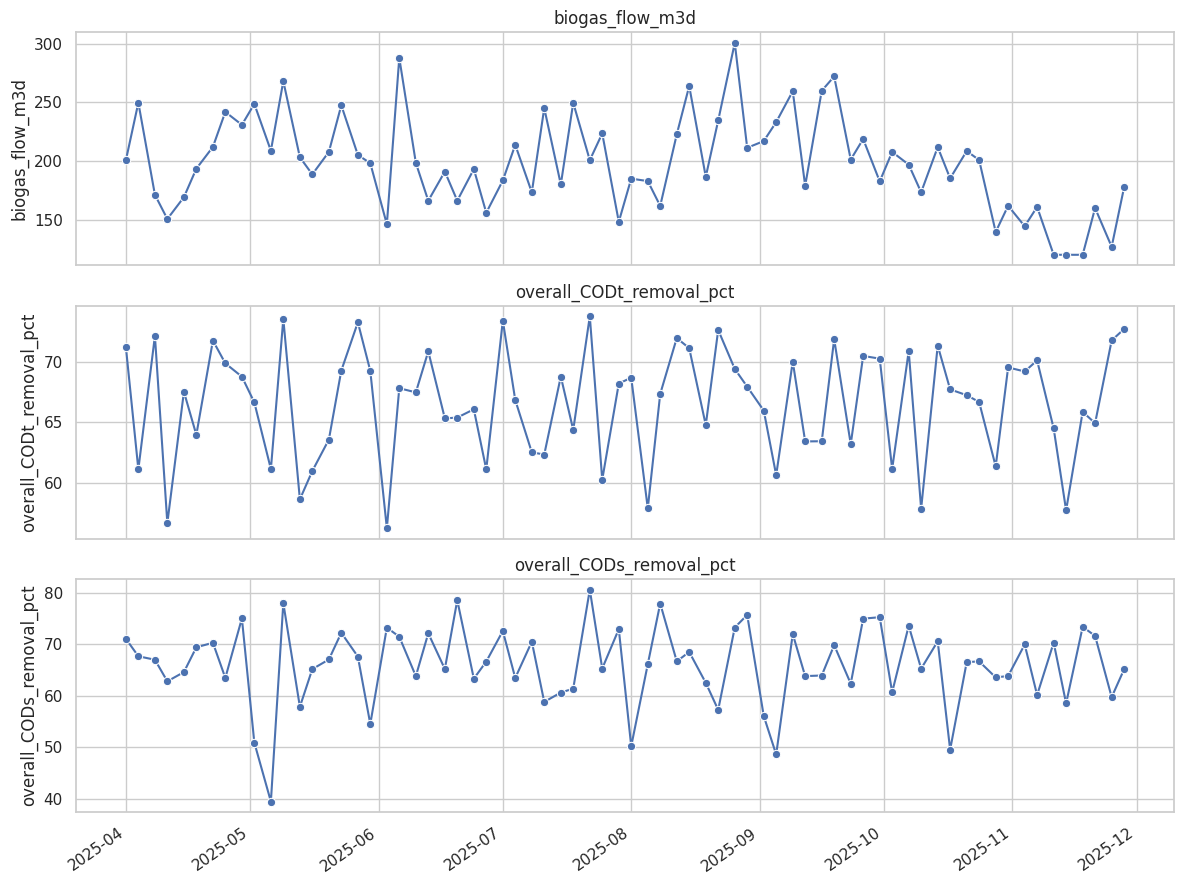

In [7]:
trend_cols = ["biogas_flow_m3d", "overall_CODt_removal_pct", "overall_CODs_removal_pct"]
trend = eda[["date"] + trend_cols].melt(id_vars="date", var_name="metric", value_name="value")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, metric in zip(axes, trend_cols):
    sns.lineplot(data=eda, x="date", y=metric, marker="o", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 5. Stage-Wise Profiles


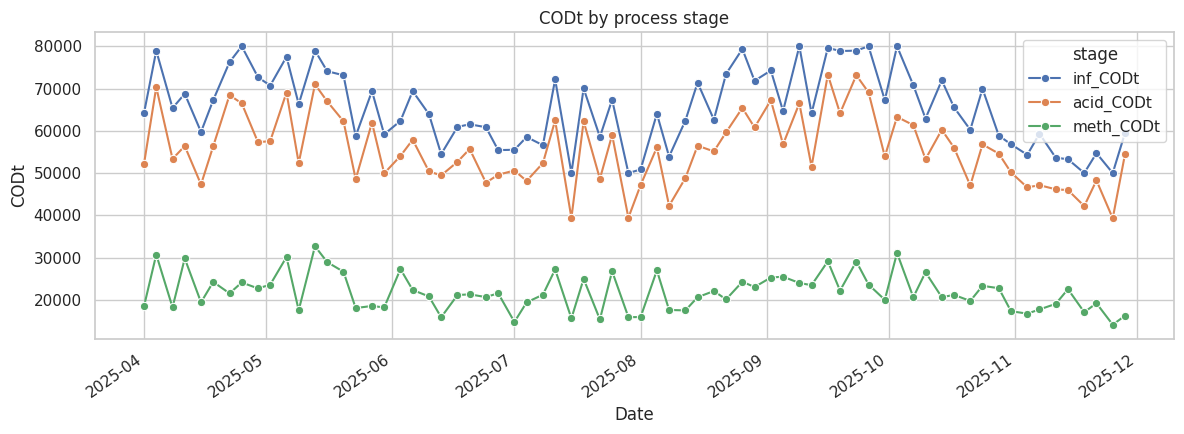

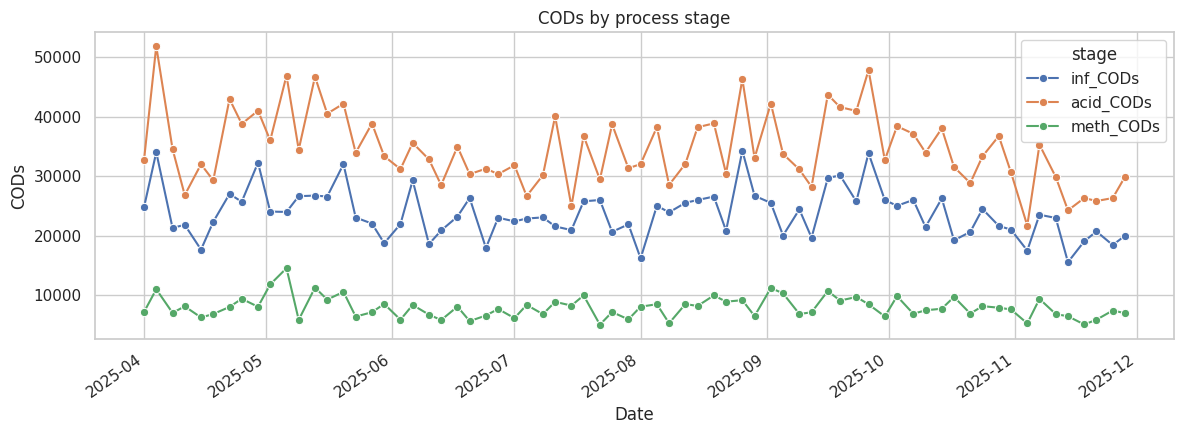

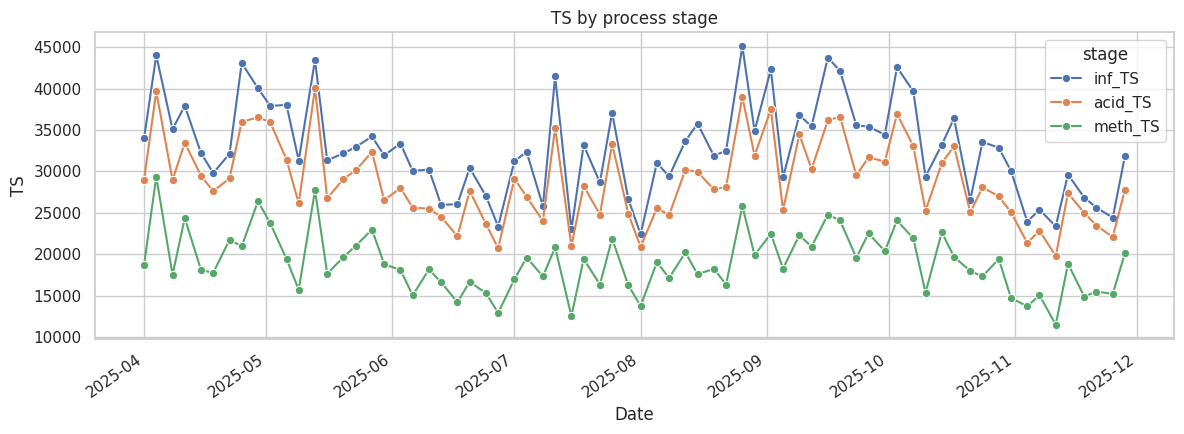

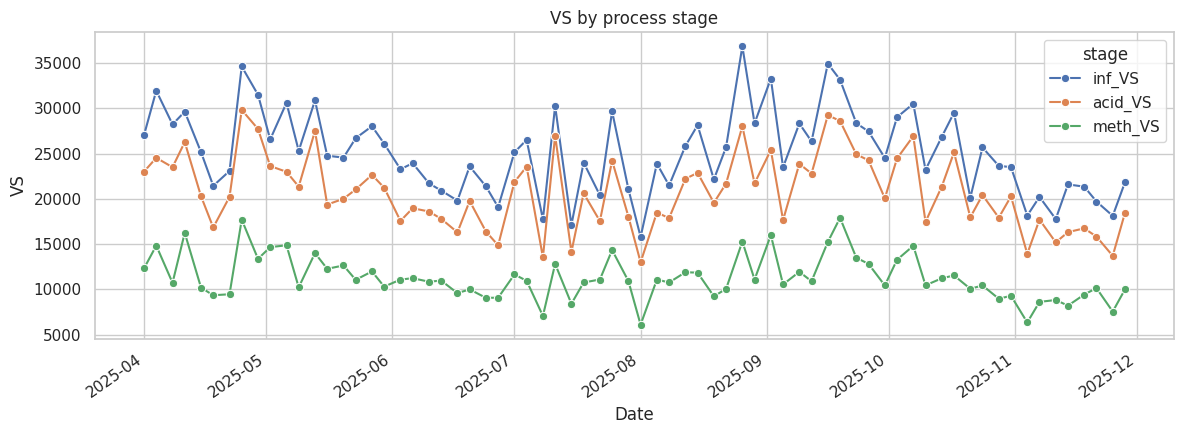

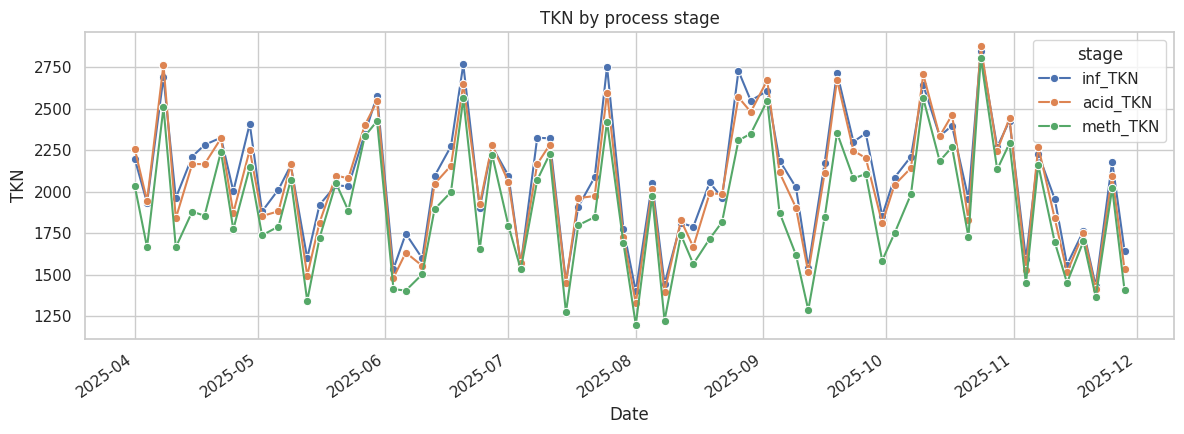

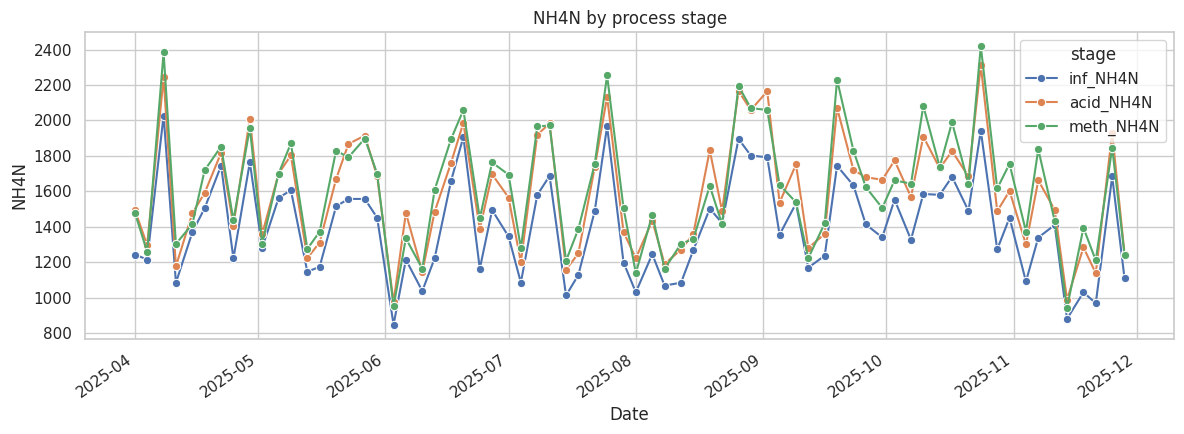

In [8]:
for analyte in ["CODt", "CODs", "TS", "VS", "TKN", "NH4N"]:
    stage_cols = [f"inf_{analyte}", f"acid_{analyte}", f"meth_{analyte}"]
    long = eda[["date"] + stage_cols].melt(id_vars="date", var_name="stage", value_name=analyte)
    plt.figure(figsize=(12, 4.5))
    sns.lineplot(data=long, x="date", y=analyte, hue="stage", marker="o")
    plt.title(f"{analyte} by process stage")
    plt.xlabel("Date")
    plt.ylabel(analyte)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


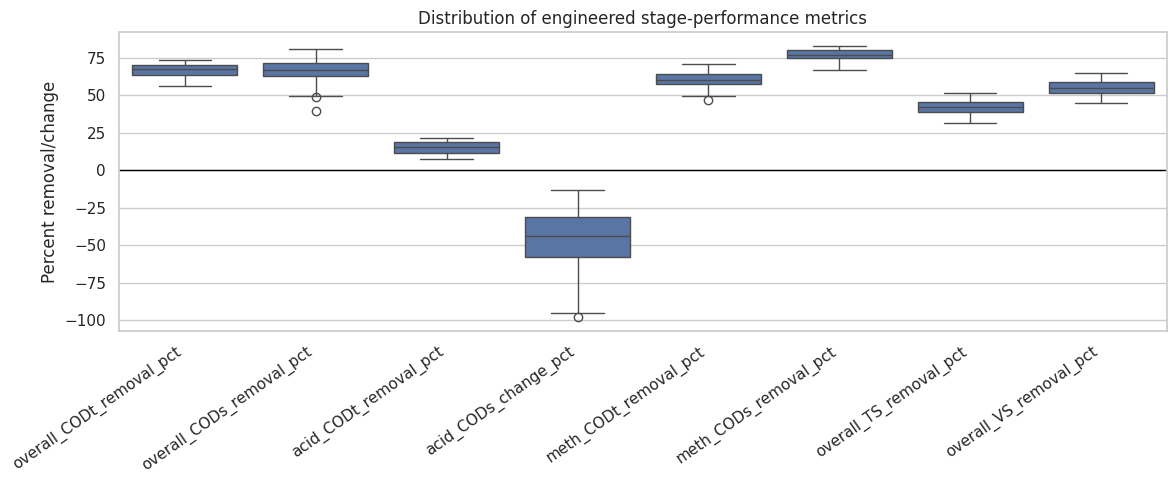

In [9]:
removal_long = eda[[
    "overall_CODt_removal_pct", "overall_CODs_removal_pct",
    "acid_CODt_removal_pct", "acid_CODs_change_pct",
    "meth_CODt_removal_pct", "meth_CODs_removal_pct",
    "overall_TS_removal_pct", "overall_VS_removal_pct",
]].melt(var_name="metric", value_name="percent")

plt.figure(figsize=(12, 5))
sns.boxplot(data=removal_long, x="metric", y="percent")
plt.axhline(0, color="black", linewidth=1)
plt.title("Distribution of engineered stage-performance metrics")
plt.xlabel("")
plt.ylabel("Percent removal/change")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


Note: `acid_CODs_change_pct` is often negative, meaning soluble COD increases in the acidogenic stage. That is plausible for hydrolysis/acidogenesis, where particulate/complex organics are converted into soluble COD before methanogenic conversion.


## 6. Biogas Production Relationships


In [10]:
candidate_cols = [c for c in eda.columns if c != "date"]
corr = eda[candidate_cols].corr(numeric_only=True)

biogas_corr = (
    corr["biogas_flow_m3d"]
    .drop("biogas_flow_m3d")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("pearson_r")
)
biogas_corr.head(15)


,pearson_r
inf_CODt,0.70
inf_VS,0.63
acid_VS,0.61
inf_TS,0.60
inf_CODs,0.60
acid_CODt,0.60
acid_CODs,0.58
acid_TS,0.58
meth_VS,0.56
meth_TS,0.51


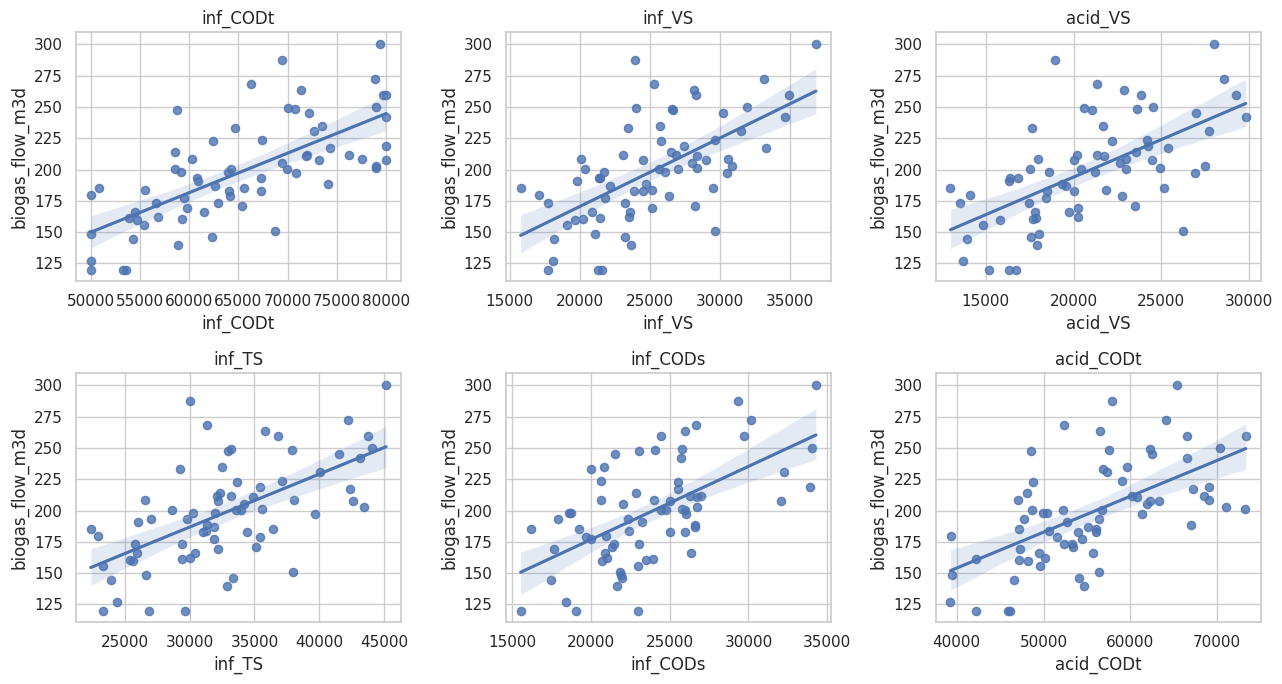

In [11]:
top_biogas_features = biogas_corr.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()
for ax, feature in zip(axes, top_biogas_features):
    sns.regplot(data=eda, x=feature, y="biogas_flow_m3d", ax=ax, scatter_kws={"s": 35})
    ax.set_title(feature)
plt.tight_layout()
plt.show()


## 7. Correlation Heatmap


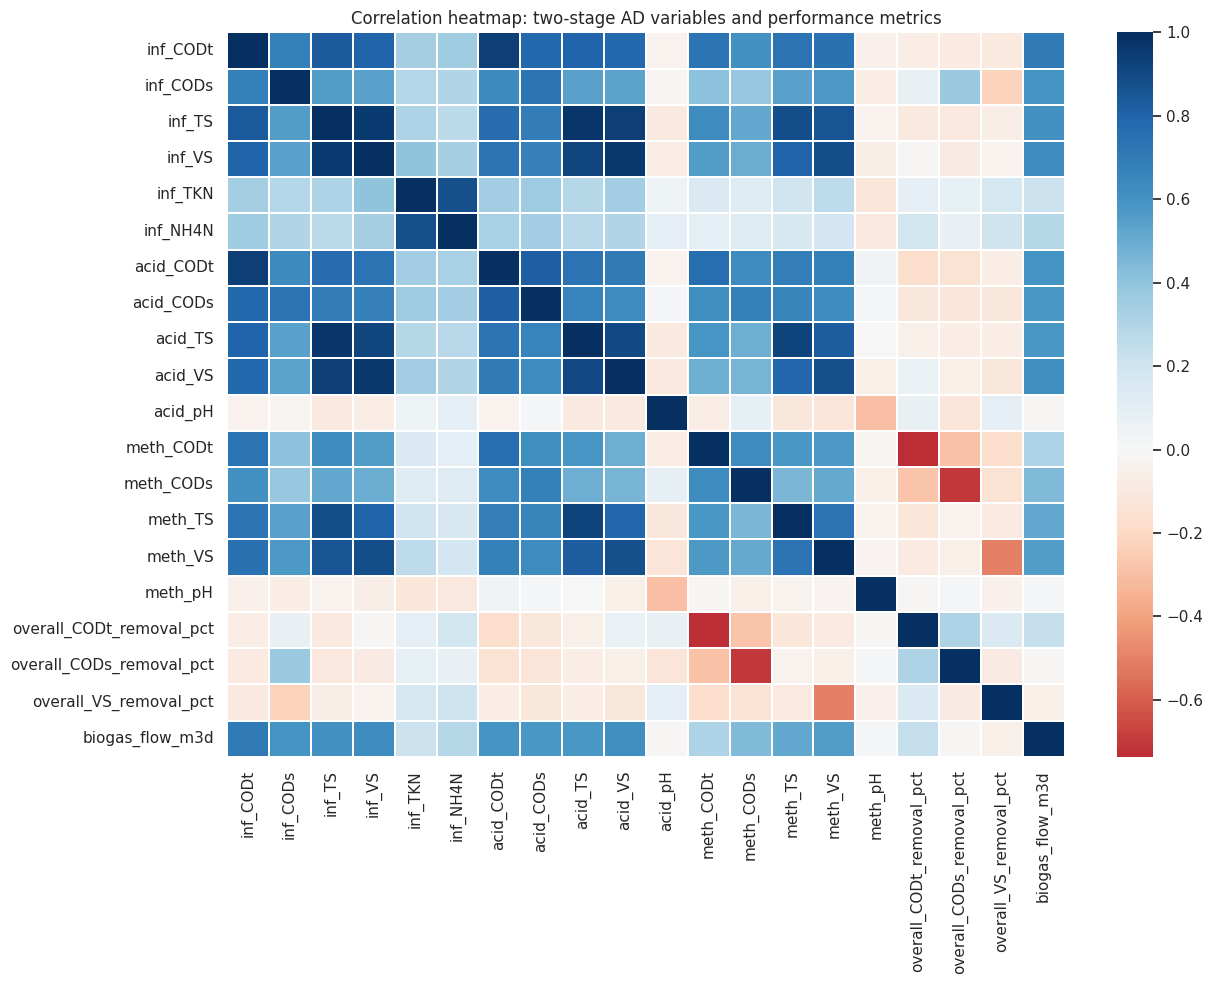

In [12]:
heatmap_cols = [
    "inf_CODt", "inf_CODs", "inf_TS", "inf_VS", "inf_TKN", "inf_NH4N",
    "acid_CODt", "acid_CODs", "acid_TS", "acid_VS", "acid_pH",
    "meth_CODt", "meth_CODs", "meth_TS", "meth_VS", "meth_pH",
    "overall_CODt_removal_pct", "overall_CODs_removal_pct", "overall_VS_removal_pct",
    "biogas_flow_m3d",
]

plt.figure(figsize=(13, 10))
sns.heatmap(eda[heatmap_cols].corr(numeric_only=True), cmap="RdBu", center=0, linewidths=0.3)
plt.title("Correlation heatmap: two-stage AD variables and performance metrics")
plt.tight_layout()
plt.show()


## 8. Modeling Readiness Notes


In [13]:
summary = {
    "n_samples": len(eda),
    "n_missing_values": int(eda.isna().sum().sum()),
    "overall_CODt_removal_mean_pct": eda["overall_CODt_removal_pct"].mean(),
    "overall_CODs_removal_mean_pct": eda["overall_CODs_removal_pct"].mean(),
    "biogas_flow_mean_m3d": eda["biogas_flow_m3d"].mean(),
    "biogas_flow_sd_m3d": eda["biogas_flow_m3d"].std(),
}
summary


{'n_samples': 70,
 'n_missing_values': 0,
 'overall_CODt_removal_mean_pct': np.float64(66.58532360104572),
 'overall_CODs_removal_mean_pct': np.float64(66.00567317729242),
 'biogas_flow_mean_m3d': np.float64(198.60085714285714),
 'biogas_flow_sd_m3d': np.float64(40.637649522025114)}

Initial assessment:

- The dataset is clean and complete, with 70 samples and no missing measurements.
- Biogas flow appears strongly related to organic loading indicators, especially influent CODt, influent VS/TS, and acid-stage COD/VS/TS.
- Overall CODt removal is dominated by methanogenic-stage CODt removal, while overall CODs removal is strongly related to methanogenic CODs removal and the acid-stage soluble COD increase/change.
- For future prediction, define the prediction timing carefully:
  - Feed-forward prediction: use only `inf_*` features to predict biogas or final removal.
  - Mid-process prediction: use `inf_*` and `acid_*` features.
  - Diagnostic/post-process modeling: may include `meth_*`, but those variables can leak final removal targets.
